In [1]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

/home/paolo/.conda/envs/pymc_env/lib/python3.12/site-packages/numpy/_core/getlimits.py:552: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [2]:
# ----------------------------
# Metric: W_alpha or Prediction Interval Coverage Probability (PICP)
# ----------------------------
def within_alpha(y_true, y_pred_samples, alpha: float, axis_draws=(0, 1)):
    """
    W_alpha: proportion of y_true inside the central alpha predictive interval.

    y_pred_samples shape examples:
      (chain, draw, n_obs)  -> axis_draws=(0,1)
      (draw, n_obs)         -> axis_draws=(0,)
    """
    y_true = np.asarray(y_true)

    if not (0.0 < alpha < 1.0):
        raise ValueError("alpha must be in (0, 1), e.g. 0.50 or 0.95. It represents a fraction!")

    # Centering of the uncertainty --> If alpha=95 then 5% of the observations will fall outside this interval and they will be split into le lowest and highest quantiles
    # the lowest quantile will be 5/2 = 2.5 and the highest quantile 100 - 2.5 = 97.5
    q_low = (1.0 - alpha) / 2.0
    q_high = 1.0 - q_low

    lower = np.quantile(y_pred_samples, q_low, axis=axis_draws)
    upper = np.quantile(y_pred_samples, q_high, axis=axis_draws)

    # Checks whether the true value lies inside the given interval
    inside = (y_true >= lower) & (y_true <= upper)
    # Computes the mean over the inner values
    return float(np.mean(inside)), lower, upper

In [3]:
files_ppc = [f"/home/paolo/Thesis/Na/pp_desc_dim_norm_Ea_dd4/pp2_model_{i}.nc" for i in range(10)]
ppcs = [az.from_netcdf(f) for f in files_ppc]


In [12]:
n_obs = 261
x = np.linspace(0, 10, n_obs)

# True function
y_true = np.sin(x) + np.random.normal(0, 0.1, n_obs)
n_chains = 4
n_draws = 4000

# Model prediction = true signal + correct noise
y_pred = (
    np.sin(x)[None, None, :] +
    np.random.normal(0, 0.1, (n_chains, n_draws, n_obs))
)

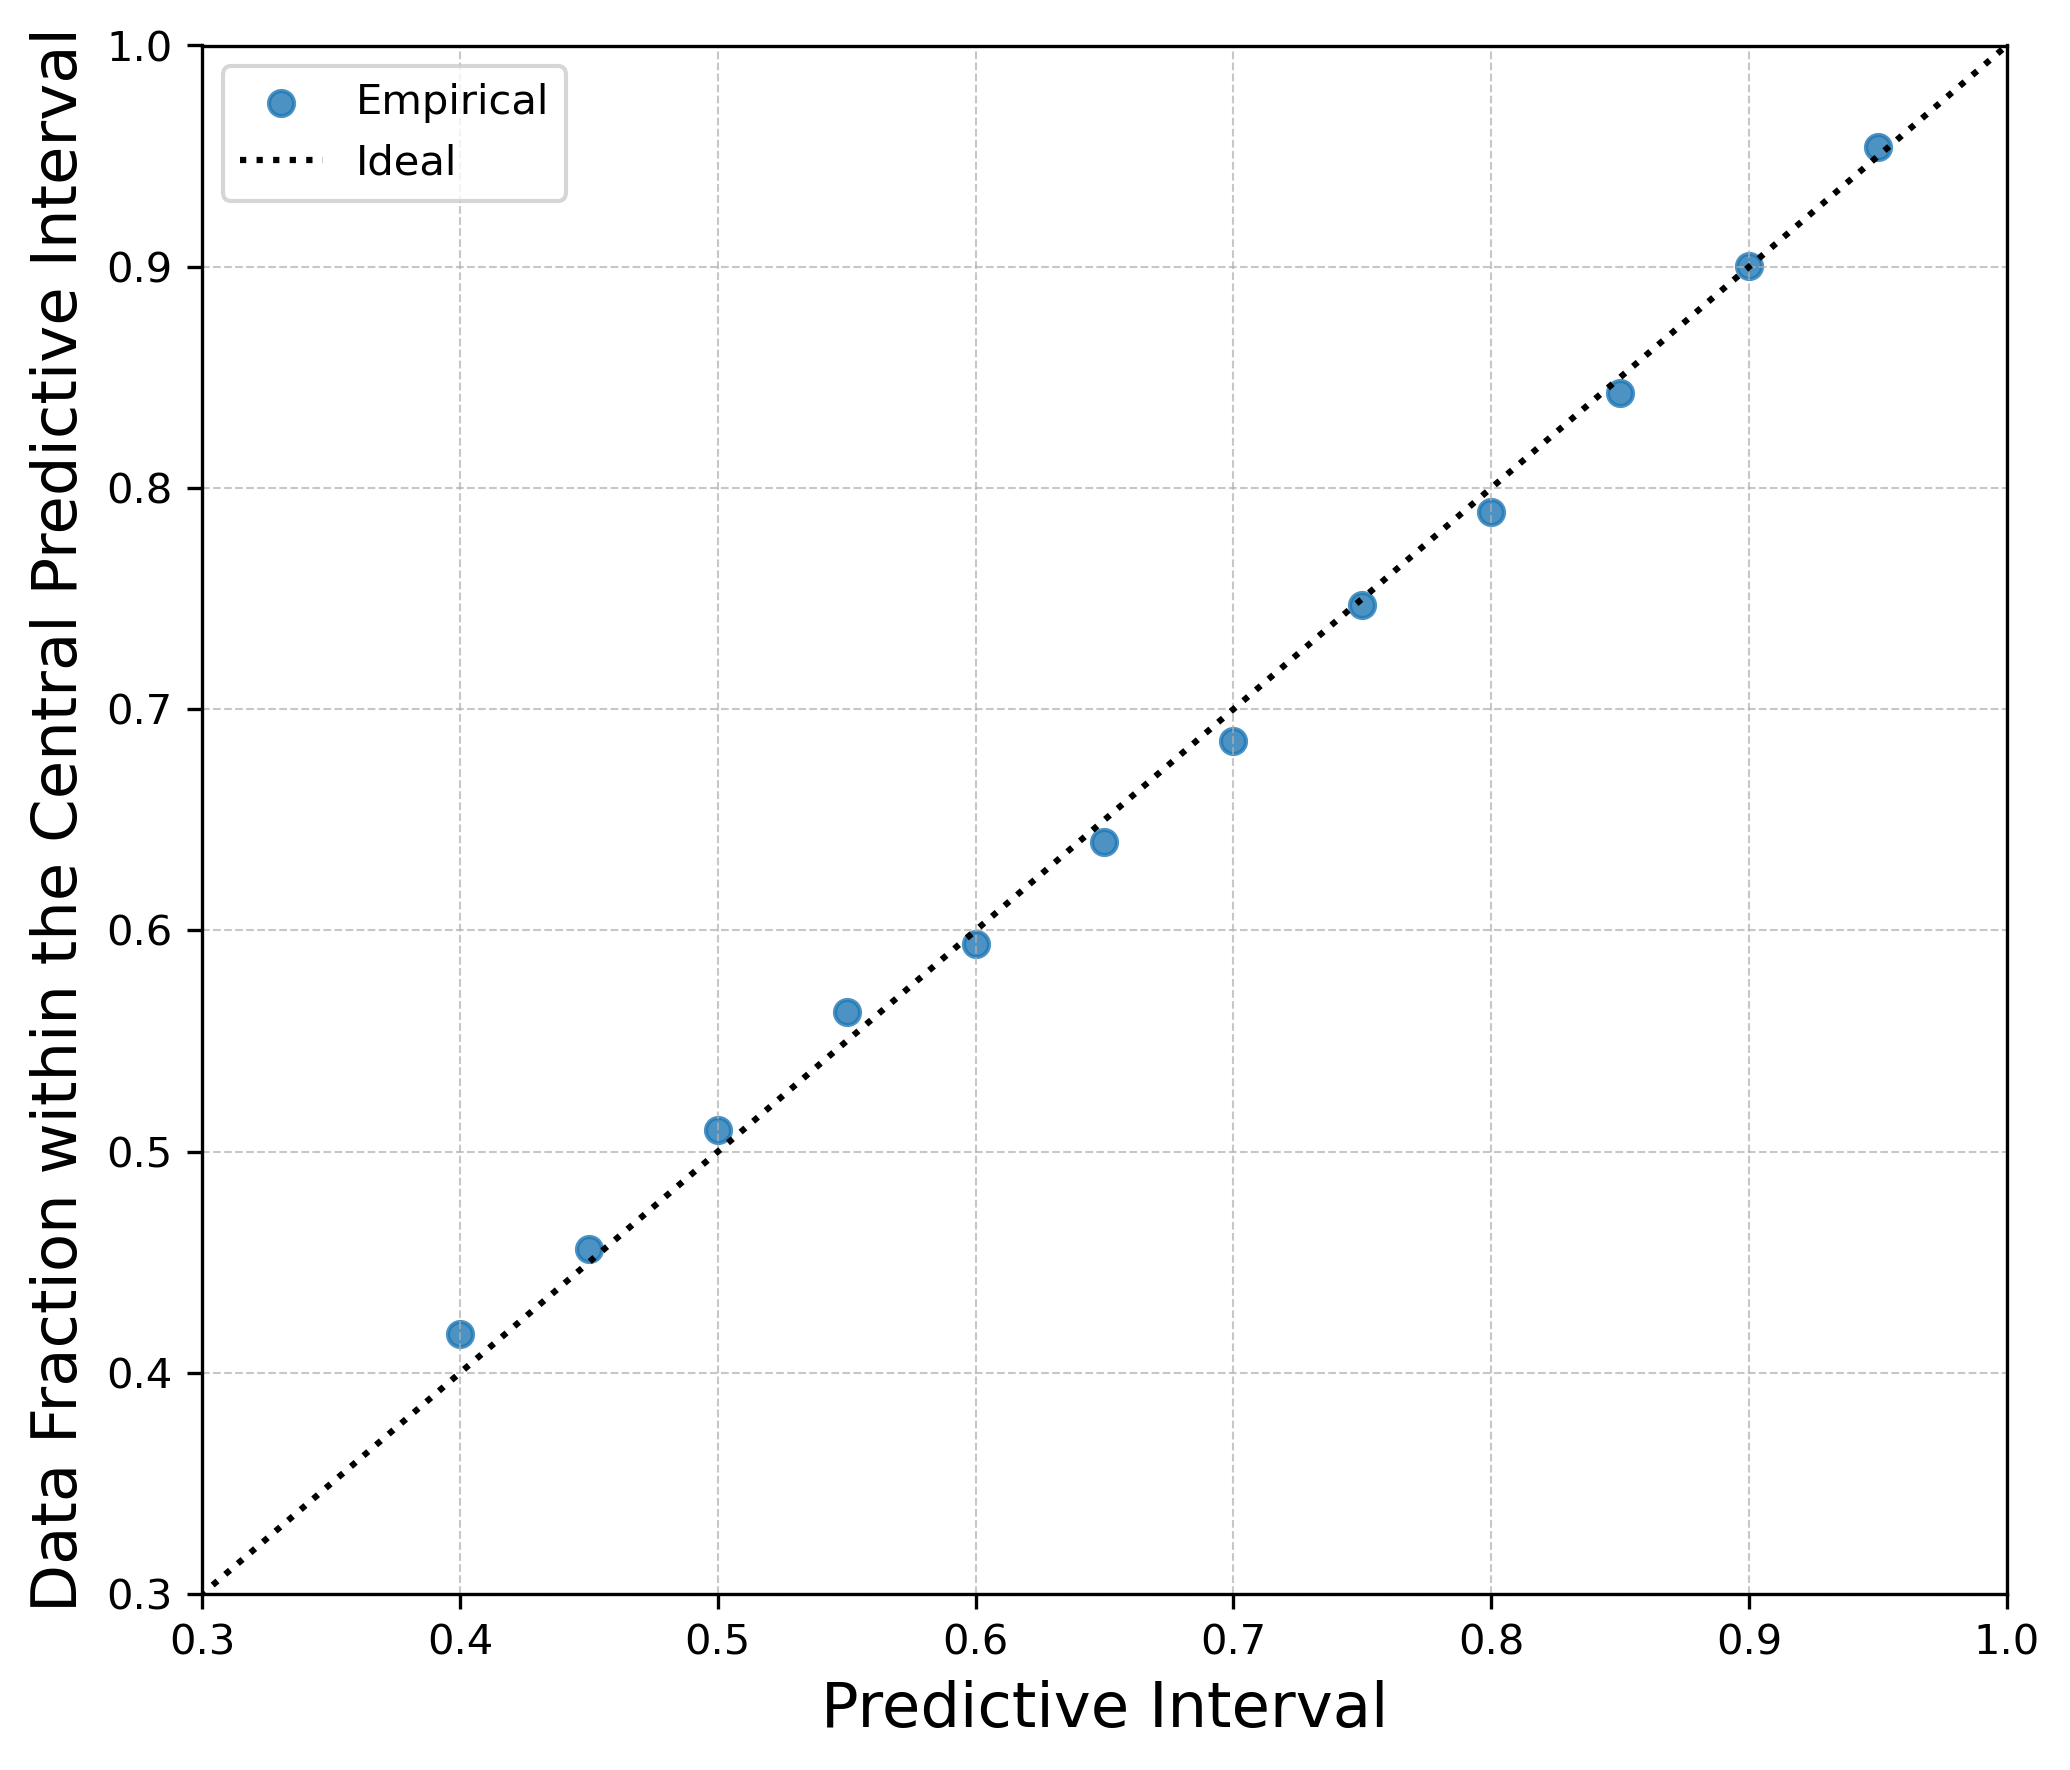

In [14]:
plt.figure(figsize=(7, 6), dpi=300)
walphas=[]
alphas = np.arange(0.4,1.0,0.05)
for alpha in alphas:
    walpha, _, _ = within_alpha(y_true, y_pred, alpha=alpha, axis_draws=(0, 1))
    walphas.append(walpha)

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.scatter(alphas,walphas, alpha=0.8, label='Empirical')
plt.ylabel('Data Fraction within the Central Predictive Interval', fontsize = 15)
plt.xlabel('Predictive Interval', fontsize = 15)
plt.plot([0,1],[0,1],linestyle=':',color='black',label='Ideal')

# Limits
plt.xlim(0.3, 1)
plt.ylim(0.3, 1)

plt.legend()
plt.tight_layout()
plt.savefig('within_alpha_sample.pdf')
plt.show()